In [5]:
import pandas as pd
from sklearn.cluster import KMeans
import math
import matplotlib.pyplot as plt
import warnings
import numpy as np
warnings.simplefilter('ignore')
from sklearn.metrics.pairwise import euclidean_distances

In [ ]:
import sqlite3

conn = sqlite3.connect('go_sales_train.sqlite')

df_branch = pd.read_sql_query("SELECT SALES_BRANCH_CODE, CITY, COUNTRY_CODE FROM sales_branch", conn)
df_country = pd.read_sql_query("SELECT COUNTRY_CODE, COUNTRY FROM country", conn)

df = pd.merge(df_branch, df_country, on='COUNTRY_CODE', how='left')

df = df[['SALES_BRANCH_CODE', 'CITY', 'COUNTRY']]

print(df.head())


   SALES_BRANCH_CODE       CITY      COUNTRY
0                  6      Paris       France
1                  7     Milano        Italy
2                  9  Amsterdam  Netherlands
3                 13    Hamburg      Germany
4                 14    München      Germany


In [ ]:
df_encoded = pd.get_dummies(df, columns=['CITY'])

print(df_encoded.head())

   SALES_BRANCH_CODE      COUNTRY  CITY_Amsterdam  CITY_Bilbao  \
0                  6       France           False        False   
1                  7        Italy           False        False   
2                  9  Netherlands            True        False   
3                 13      Germany           False        False   
4                 14      Germany           False        False   

   CITY_Birmingham  CITY_Boston  CITY_Calgary  CITY_Distrito Federal  \
0            False        False         False                  False   
1            False        False         False                  False   
2            False        False         False                  False   
3            False        False         False                  False   
4            False        False         False                  False   

   CITY_Hamburg  CITY_Heverlee  ...  CITY_Paris  CITY_San Chung  CITY_Seattle  \
0         False          False  ...        True           False         False   
1       

In [9]:
df_final = pd.get_dummies(df_encoded, columns=['COUNTRY'])
print(df_final.head())

   SALES_BRANCH_CODE  CITY_Amsterdam  CITY_Bilbao  CITY_Birmingham  \
0                  6           False        False            False   
1                  7           False        False            False   
2                  9            True        False            False   
3                 13           False        False            False   
4                 14           False        False            False   

   CITY_Boston  CITY_Calgary  CITY_Distrito Federal  CITY_Hamburg  \
0        False         False                  False         False   
1        False         False                  False         False   
2        False         False                  False         False   
3        False         False                  False          True   
4        False         False                  False         False   

   CITY_Heverlee  CITY_Kista  ...  COUNTRY_Japan  COUNTRY_Korea  \
0          False       False  ...          False          False   
1          False       False  

In [10]:
features = [col for col in df_final.columns if col.startswith('CITY_') or col.startswith('COUNTRY_')]
X = df_final[features]

print(X.head())

   CITY_Amsterdam  CITY_Bilbao  CITY_Birmingham  CITY_Boston  CITY_Calgary  \
0           False        False            False        False         False   
1           False        False            False        False         False   
2            True        False            False        False         False   
3           False        False            False        False         False   
4           False        False            False        False         False   

   CITY_Distrito Federal  CITY_Hamburg  CITY_Heverlee  CITY_Kista  \
0                  False         False          False       False   
1                  False         False          False       False   
2                  False         False          False       False   
3                  False          True          False       False   
4                  False         False          False       False   

   CITY_Kuopio  ...  COUNTRY_Japan  COUNTRY_Korea  COUNTRY_Mexico  \
0        False  ...          False          Fal

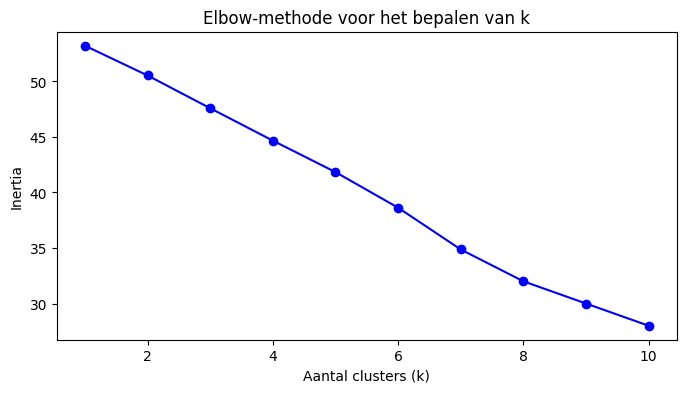

In [ ]:
inertia = []
K = range(1, 11) 

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X.astype(int))  
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Aantal clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow-methode voor het bepalen van k')
plt.show()


In [ ]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X.astype(int))

df['Cluster'] = clusters

print(df.head())

   SALES_BRANCH_CODE       CITY      COUNTRY  Cluster
0                  6      Paris       France        1
1                  7     Milano        Italy        0
2                  9  Amsterdam  Netherlands        0
3                 13    Hamburg      Germany        2
4                 14    München      Germany        2


In [ ]:
print(df['Cluster'].value_counts())

print(df.groupby('Cluster')['COUNTRY'].value_counts())

print(df.groupby('Cluster')['CITY'].value_counts())

Cluster
0    18
1     8
2     2
Name: count, dtype: int64
Cluster  COUNTRY       
0        United States     4
         Australia         1
         Austria           1
         Belgium           1
         Brazil            1
         Canada            1
         China             1
         Finland           1
         Italy             1
         Korea             1
         Mexico            1
         Netherlands       1
         Spain             1
         Sweden            1
         Switzerland       1
1        France            2
         Japan             2
         United Kingdom    2
         Canada            1
         Taiwan            1
2        Germany           2
Name: count, dtype: int64
Cluster  CITY            
0        Amsterdam           1
         Bilbao              1
         Boston              1
         Calgary             1
         Distrito Federal    1
         Heverlee            1
         Kista               1
         Kuopio              1
         

In [ ]:
from sklearn.metrics import pairwise_distances

intra_distances = []
for i in range(k):
    cluster_points = X[kmeans.labels_ == i]
    center = kmeans.cluster_centers_[i]
    distances = np.linalg.norm(cluster_points - center, axis=1)
    intra_distances.append(distances.mean())
print("Gemiddelde intraclusterafstand per cluster:", intra_distances)

inter_distances = pairwise_distances(kmeans.cluster_centers_)
print("Interclusterafstanden tussen de centra:\n", inter_distances)

Gemiddelde intraclusterafstand per cluster: [np.float64(1.359822288404675), np.float64(1.2862904783214515), np.float64(0.7071067811865476)]
Interclusterafstanden tussen de centra:
 [[0.         0.69138214 1.28380222]
 [0.69138214 0.         1.35784756]
 [1.28380222 1.35784756 0.        ]]


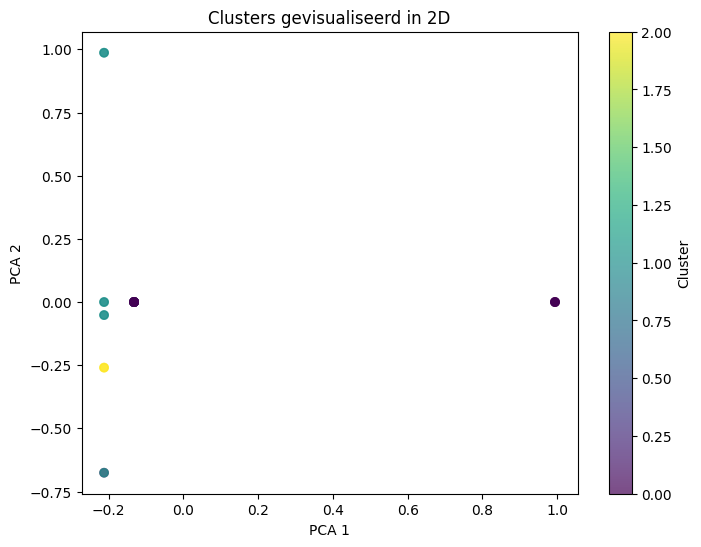

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters gevisualiseerd in 2D')
plt.colorbar(label='Cluster')
plt.show()